In [1]:
%cd /home/ytee/test/trade_bot/

from src.csv.msci import MSCI
import numpy as np
from finagg.fred.api import CategorySeries, SeriesObservations,SeriesCategories,Tags
import pandas as pd
so = SeriesObservations()
sc = SeriesCategories()
ret= []

def get_series(eventid):
    metadata = sc.get(eventid)
    eclass = metadata.iloc[-1]['name']
    df = so.get(eventid )[['series_id', 'value', 'date']]
    df.columns= ['event', 'actual', 'datetime']
    df['eclass'] = eclass
    df['datetime'] = pd.to_datetime(df.datetime)
    return df



app = MSCI()
data = app.get_all_msci_codes()

/home/ytee/test/trade_bot/venv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/ytee/test/trade_bot


<Axes: xlabel='date'>

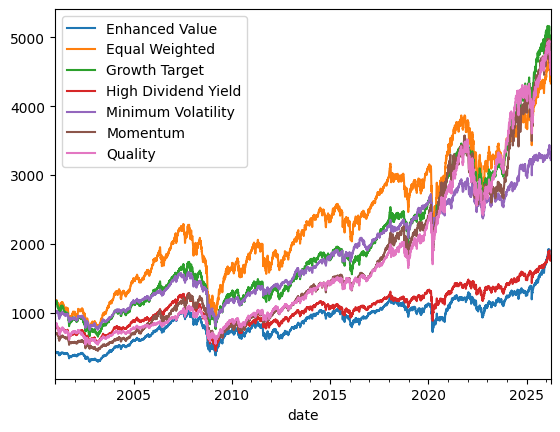

In [2]:
xx = app.get_all('World')
xx.plot()


<Axes: xlabel='date'>

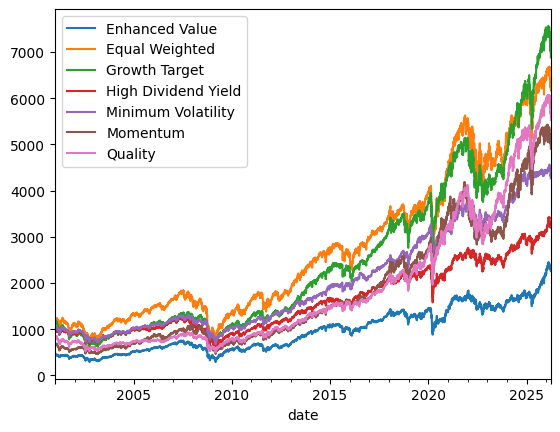

In [3]:
xx = app.get_all('US')
xx.plot()

In [4]:
us10yr=  get_series('DGS10').set_index('datetime')['actual']
us2yr=  get_series('DGS2').set_index('datetime')['actual']
us3mo = get_series('DGS3MO').set_index('datetime')['actual']
df = pd.concat([
    us10yr.rename('y10'),
    us2yr.rename('y2'),
    us3mo.rename('y3m')
], axis=1).dropna()




In [5]:
import matplotlib.pyplot as plt
import datetime
msci_monthly = xx.resample('ME').last()
msci_monthly = msci_monthly[msci_monthly.index > datetime.datetime(2020,1,1)]
msci_roi_1m = msci_monthly.pct_change().shift(-1)

yield_monthly = df[['y10', 'y2', 'y3m']].resample('ME').last().dropna()
yield_monthly['d_short'] = yield_monthly['y2'].diff()
yield_monthly['d_long'] = yield_monthly['y10'].diff()


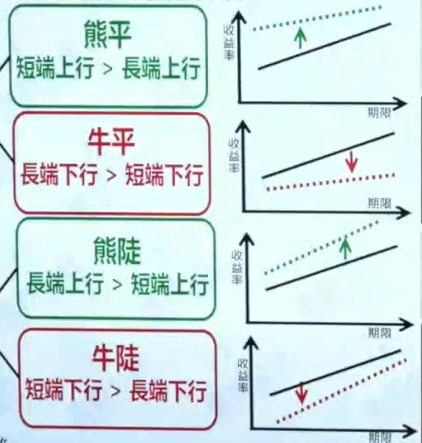

In [6]:
from PIL import Image
from IPython.display import display

def regime_classification(row):
    if abs(row['d_short']) > abs(row['d_long']):
        # then focus on short
        if row['d_short'] < 0:
            return 'bull_steep' # short term rate goes down
        else:
            return 'bear_flat' #short term rate goes up 
    else:
        # focus on long
        if row['d_long'] < 0:
            return 'bull_flat'
        else:
            return 'bear_steep'
img = Image.open("images/yield_curve_reference.png")
display(img)

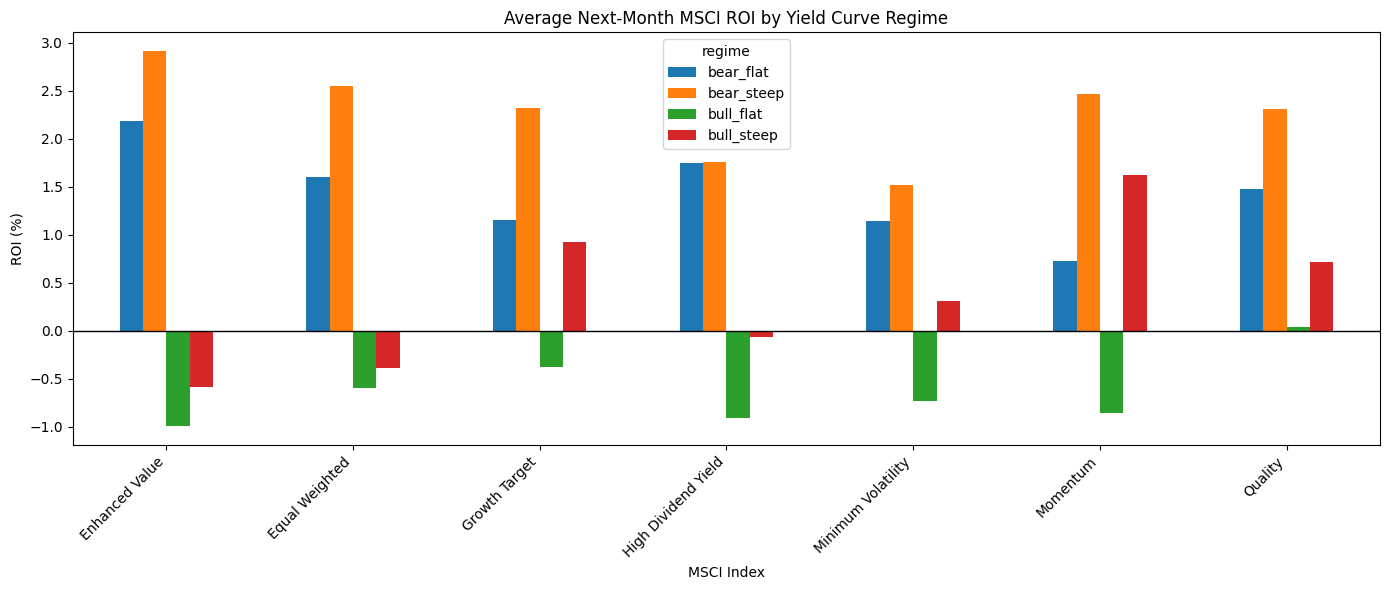

In [7]:
regime = yield_monthly.apply(regime_classification, axis=1)
regime.name = 'regime'

analysis = msci_roi_1m.join(regime, how='inner').dropna(subset=['regime'])
avg_roi = analysis.groupby('regime')[msci_roi_1m.columns].mean().T * 100

ax = avg_roi.plot(kind='bar', figsize=(14, 6))
ax.set_title('Average Next-Month MSCI ROI by Yield Curve Regime')
ax.set_ylabel('ROI (%)')
ax.set_xlabel('MSCI Index')
ax.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

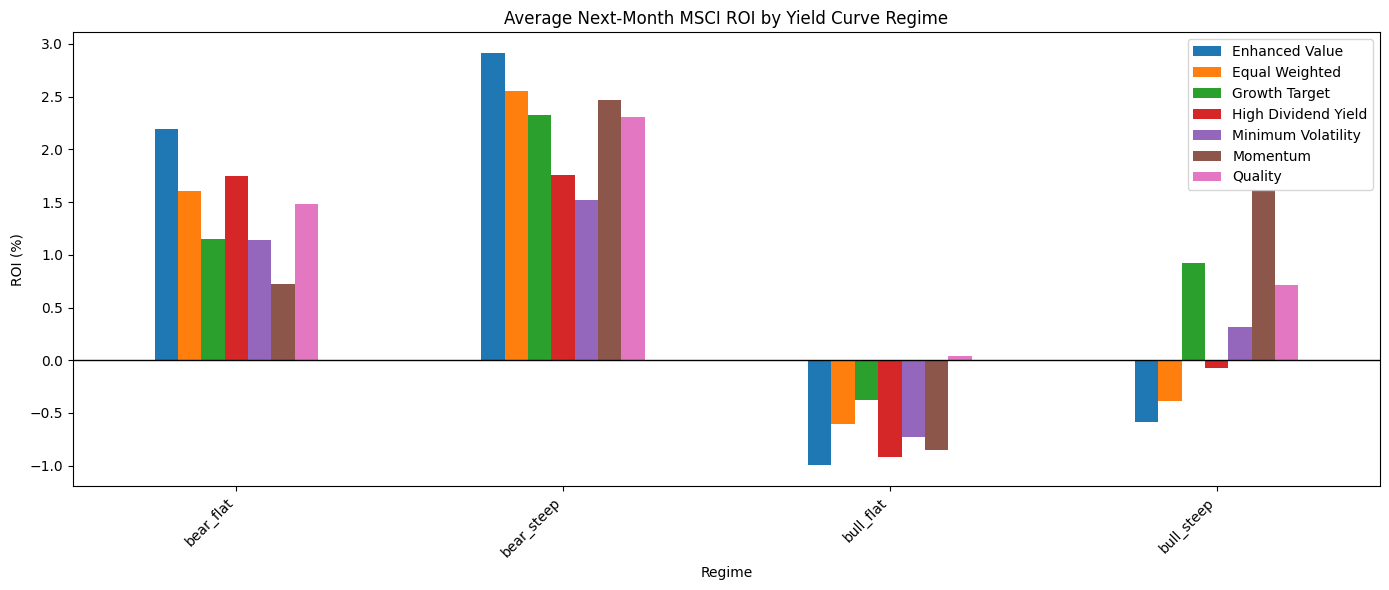

In [8]:
avg_roi = analysis.groupby('regime')[msci_roi_1m.columns].mean() * 100

ax = avg_roi.plot(kind='bar', figsize=(14, 6))
ax.set_title('Average Next-Month MSCI ROI by Yield Curve Regime')
ax.set_ylabel('ROI (%)')
ax.set_xlabel('Regime')
ax.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

y10               14.63
y2                14.59
y3m               13.33
d_short            -2.1
d_long            -1.21
regime       bull_steep
y10_shift         15.84
y2_shift          16.69
Name: 1981-10-31 00:00:00, dtype: object

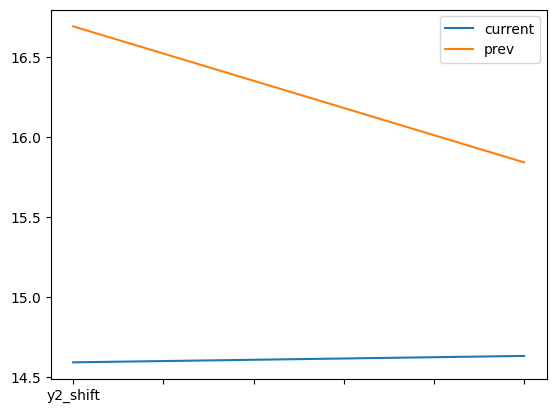

In [9]:
yield_monthly['regime'] =regime

yield_monthly['y10_shift'] = yield_monthly['y10'].shift(1)
yield_monthly['y2_shift'] = yield_monthly['y2'].shift(1)

idx = 0
yield_monthly[yield_monthly.regime=='bull_steep'][[ 'y2', 'y10']].iloc[idx].plot(label='current')
ax = yield_monthly[yield_monthly.regime=='bull_steep'][[ 'y2_shift', 'y10_shift']].iloc[idx].plot(label='prev')
ax.legend()
yield_monthly[yield_monthly.regime=='bull_steep'].iloc[0]